In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw
from matplotlib.lines import Line2D
from collections import Counter


plt.rcParams['figure.dpi'] = 300

In [2]:
# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

DOCKING_RESULTS = {}
# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):
    # Get scores
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))
    # Save results
    DOCKING_RESULTS[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

# Sort pockets by median
pockets = sorted(DOCKING_RESULTS)
medians = [np.median(list(DOCKING_RESULTS[p].values())) for p in pockets]
ind = np.argsort(medians)
pockets = np.array(pockets)[ind]

del DOCKING_RESULTS

100%|██████████| 276/276 [01:58<00:00,  2.34it/s]


In [3]:
# Load labels
root = '.'
PATH_TO_PROBS = os.path.join(root, "..", "processed", "unidock_docking", "inference_probs")
labels = np.array(pickle.load(open(os.path.join(PATH_TO_PROBS, "success_mols.pkl"), "rb")))

pocket_to_probs = {}
pocket_to_all_probs = {}
TOPs = [10, 100, 1000, 10000, 100000]
cmap = plt.cm.viridis
colors_to_use = cmap(np.linspace(0, 1, len(TOPs)))

# For each pocket
for c, pocket in tqdm(enumerate(pockets)):

    pocket_to_probs[pocket] = {}

    # Load probs
    probs = np.load(os.path.join(PATH_TO_PROBS, f"{pocket}_bin_01.npz"))["arr_0"]
    pocket_to_all_probs[pocket] = probs
    probs = np.sort(probs)[::-1]
    for TOP in TOPs:
        pocket_to_probs[pocket][TOP] = probs[TOP]

276it [01:06,  4.13it/s]


In [4]:
# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

protein_to_pockets = {i: set() for i in sorted(set(pocket_detection_data['Uniprot AC']))}
pocket_to_coords = {}

for file, pocket_numb, coord in zip(pocket_detection_data['File name'], 
                             pocket_detection_data['Pocket number'],
                             pocket_detection_data['Pocket centroid coordinate (x y z)']):
    
    # Prepare labels
    label = file.replace(".pdb", "") + "_pocket_" + str(pocket_numb)
    protein = file.split("_")[1]

    # Create mappings
    protein_to_pockets[protein].add(label)
    pocket_to_coords[label] = np.array(coord.split(), dtype=float)

# Load pocketvec descriptors
fps_tRNAs = pickle.load(open("../processed/pocketvec_RUN/fps_rank.pkl", 'rb'))

# Get outliers
outliers = {i: len(np.where(fps_tRNAs[i] > 128)[0]) for i in sorted(fps_tRNAs)}

# Filter unreliable tRNA descriptors
fps_tRNAs = {i: fps_tRNAs[i] for i in sorted(fps_tRNAs) if outliers[i] < 80}

In [5]:
### PROBABILITIES PER POCKET ###

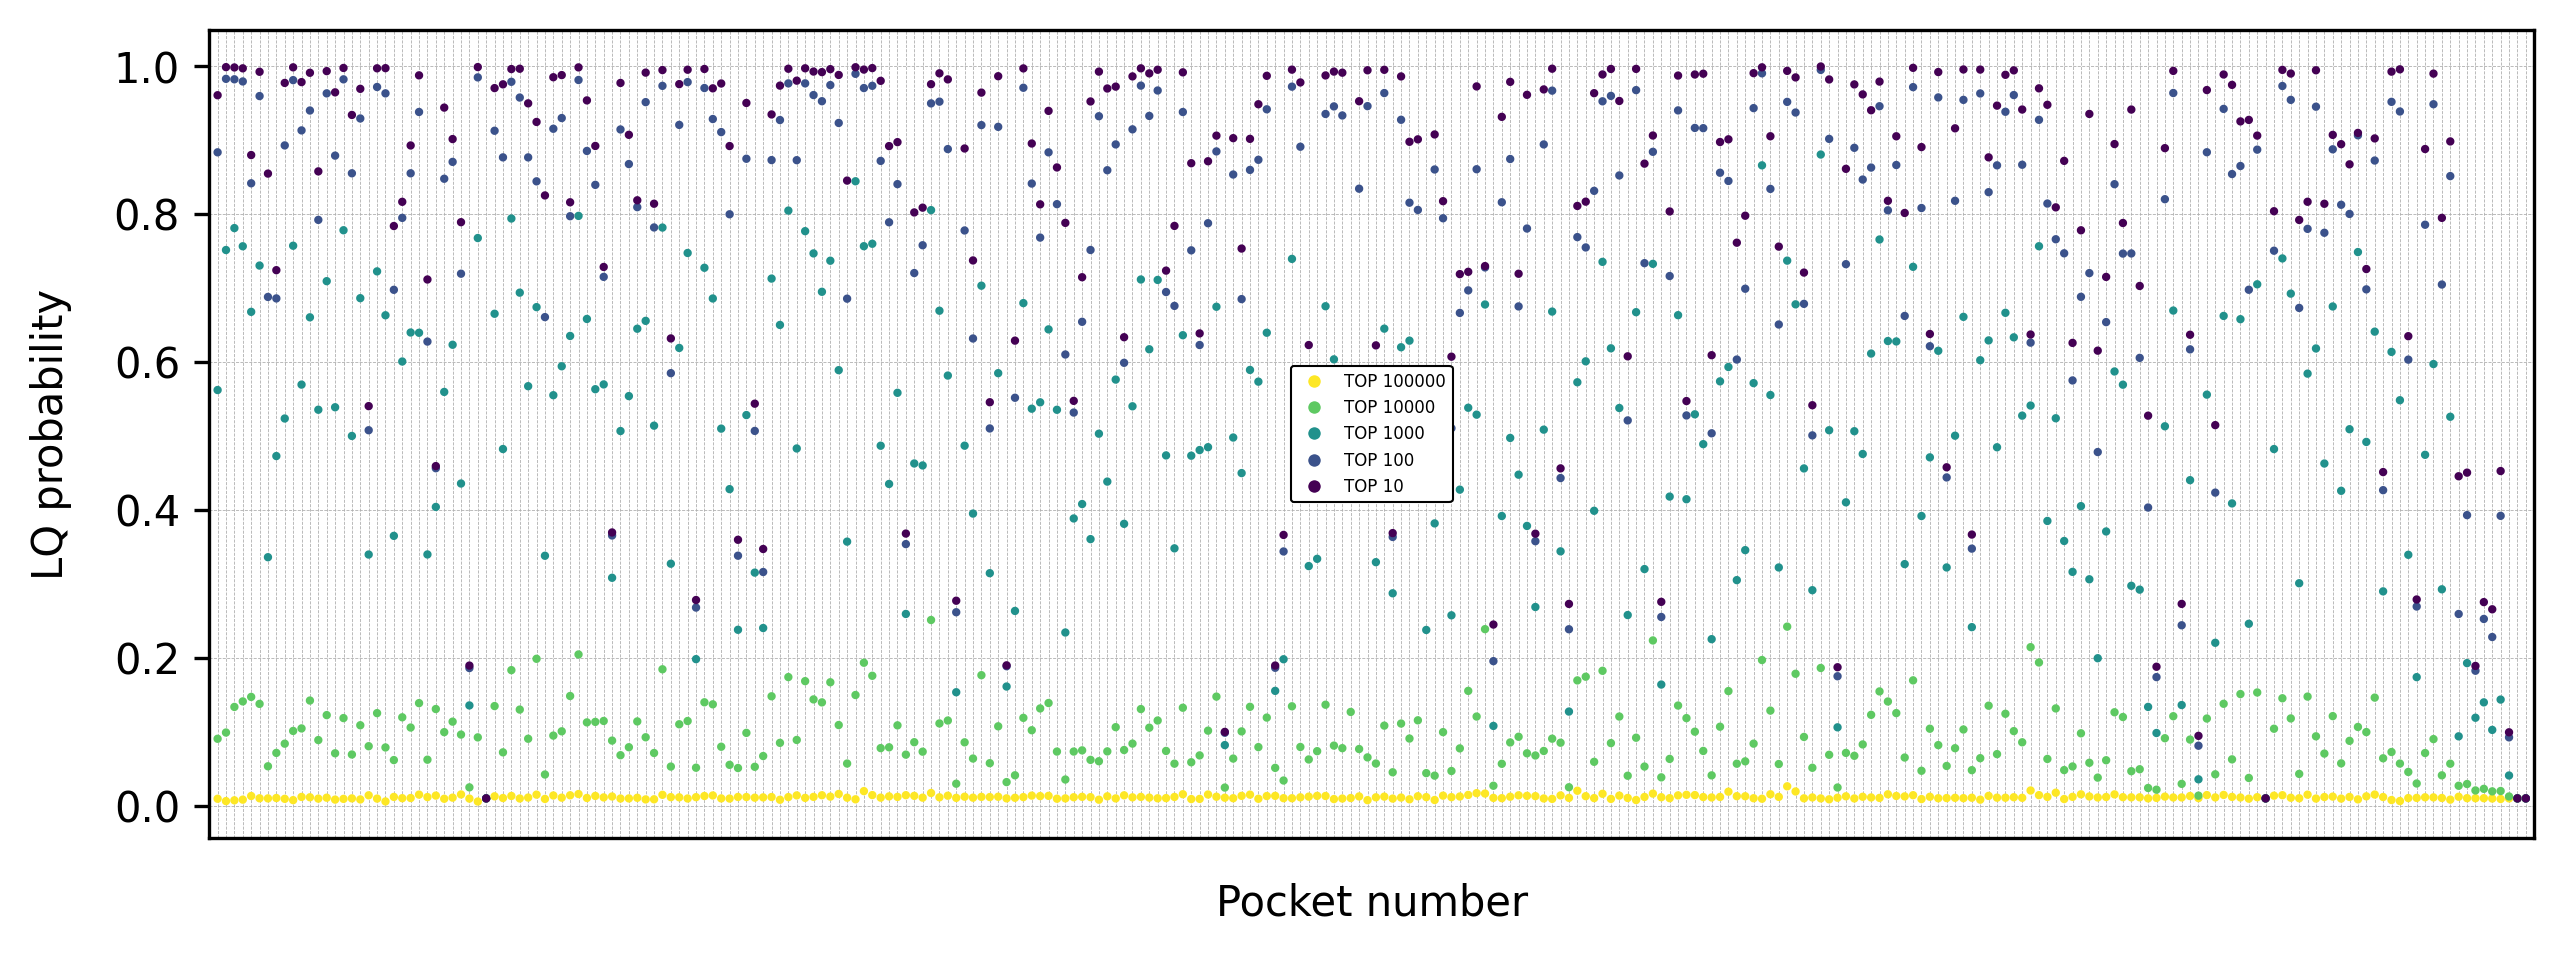

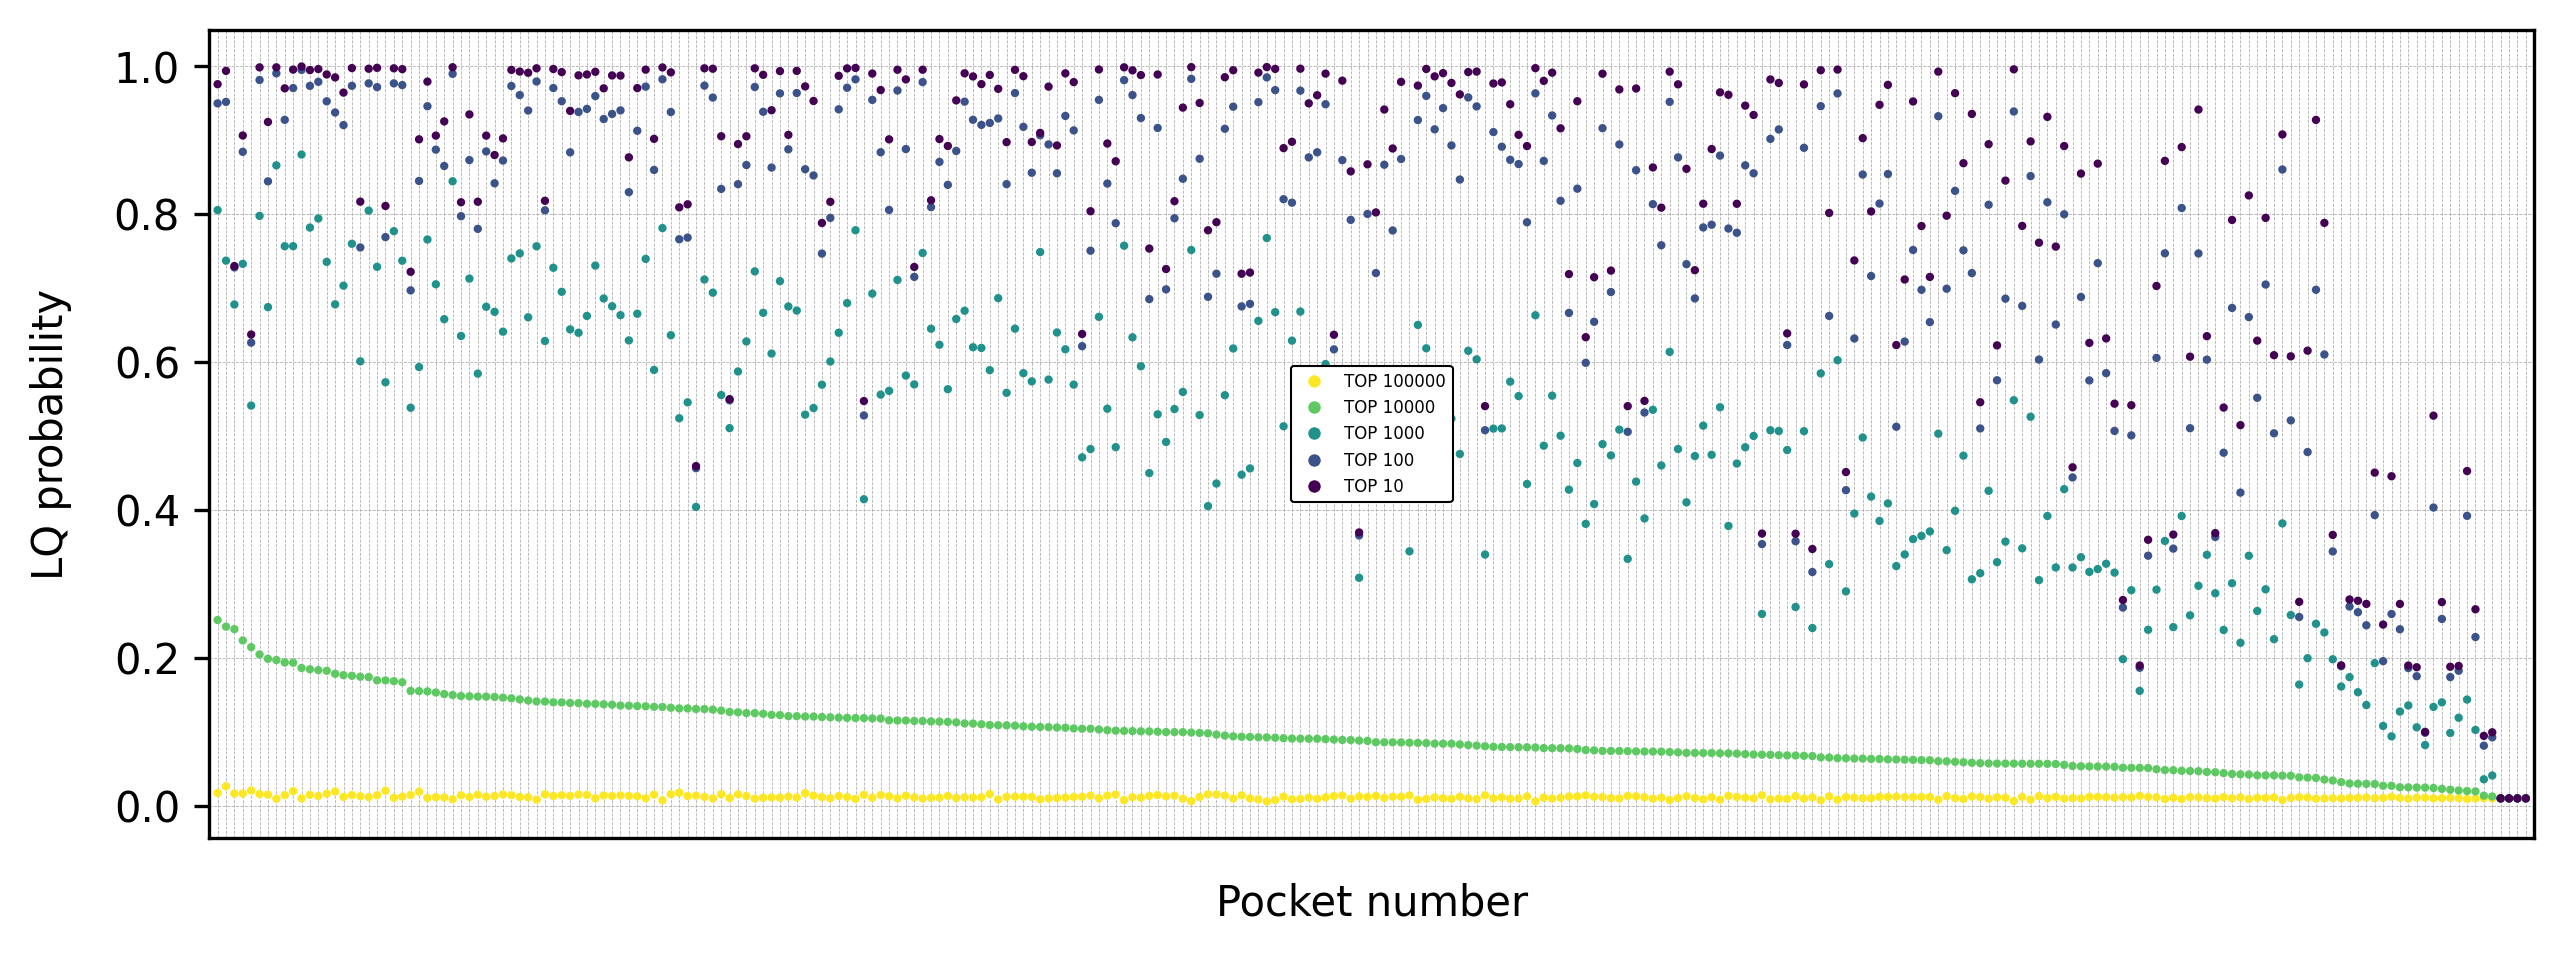

In [6]:
x, y, colors = [], [], []
for c, pocket in enumerate(pockets):
    for color, TOP in zip(colors_to_use[::-1], TOPs[::-1]):
        x.append(c)
        y.append(pocket_to_probs[pocket][TOP])
        colors.append(color)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f"TOP {TOP}",
           markerfacecolor=color, markersize=4, linestyle="None")
    for color, TOP in zip(colors_to_use[::-1], TOPs[::-1])
]
 
fig, ax = plt.subplots(figsize=(10, 3.5))
plt.scatter(x, y, c=colors, zorder=2, s=1)
plt.xticks([i for i in range(len(pockets))], ["" for i in range(len(pockets))])
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("LQ probability", labelpad=10)
plt.xlim([-1, 276])
l = plt.legend(handles=legend_elements, prop={'size':4}, edgecolor='k', framealpha=1, loc='center')
l.get_frame().set_linewidth(0.5)
plt.show()


x, y, colors = [], [], []
pockets_sorted = sorted(pockets, key = lambda x: pocket_to_probs[x][10000])[::-1]
for c, pocket in enumerate(pockets_sorted):
    for color, TOP in zip(colors_to_use[::-1], TOPs[::-1]):
        x.append(c)
        y.append(pocket_to_probs[pocket][TOP])
        colors.append(color)
 
fig, ax = plt.subplots(figsize=(10, 3.5))
plt.scatter(x, y, c=colors, zorder=2, s=1)
plt.xticks([i for i in range(len(pockets))], ["" for i in range(len(pockets))])
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("LQ probability", labelpad=10)
plt.xlim([-1, 276])
l = plt.legend(handles=legend_elements, prop={'size':4}, edgecolor='k', framealpha=1, loc='center')
l.get_frame().set_linewidth(0.5)
plt.show()

In [7]:
pocket_to_prob_mean = {}
pocket_to_prob_median = {}
pocket_to_prob_std = {}

for pocket in tqdm(sorted(pocket_to_all_probs)):
    pocket_to_prob_mean[pocket] = np.mean(pocket_to_all_probs[pocket])
    pocket_to_prob_median[pocket] = np.median(pocket_to_all_probs[pocket])
    pocket_to_prob_std[pocket] = np.std(pocket_to_all_probs[pocket])

100%|██████████| 276/276 [00:30<00:00,  9.20it/s]


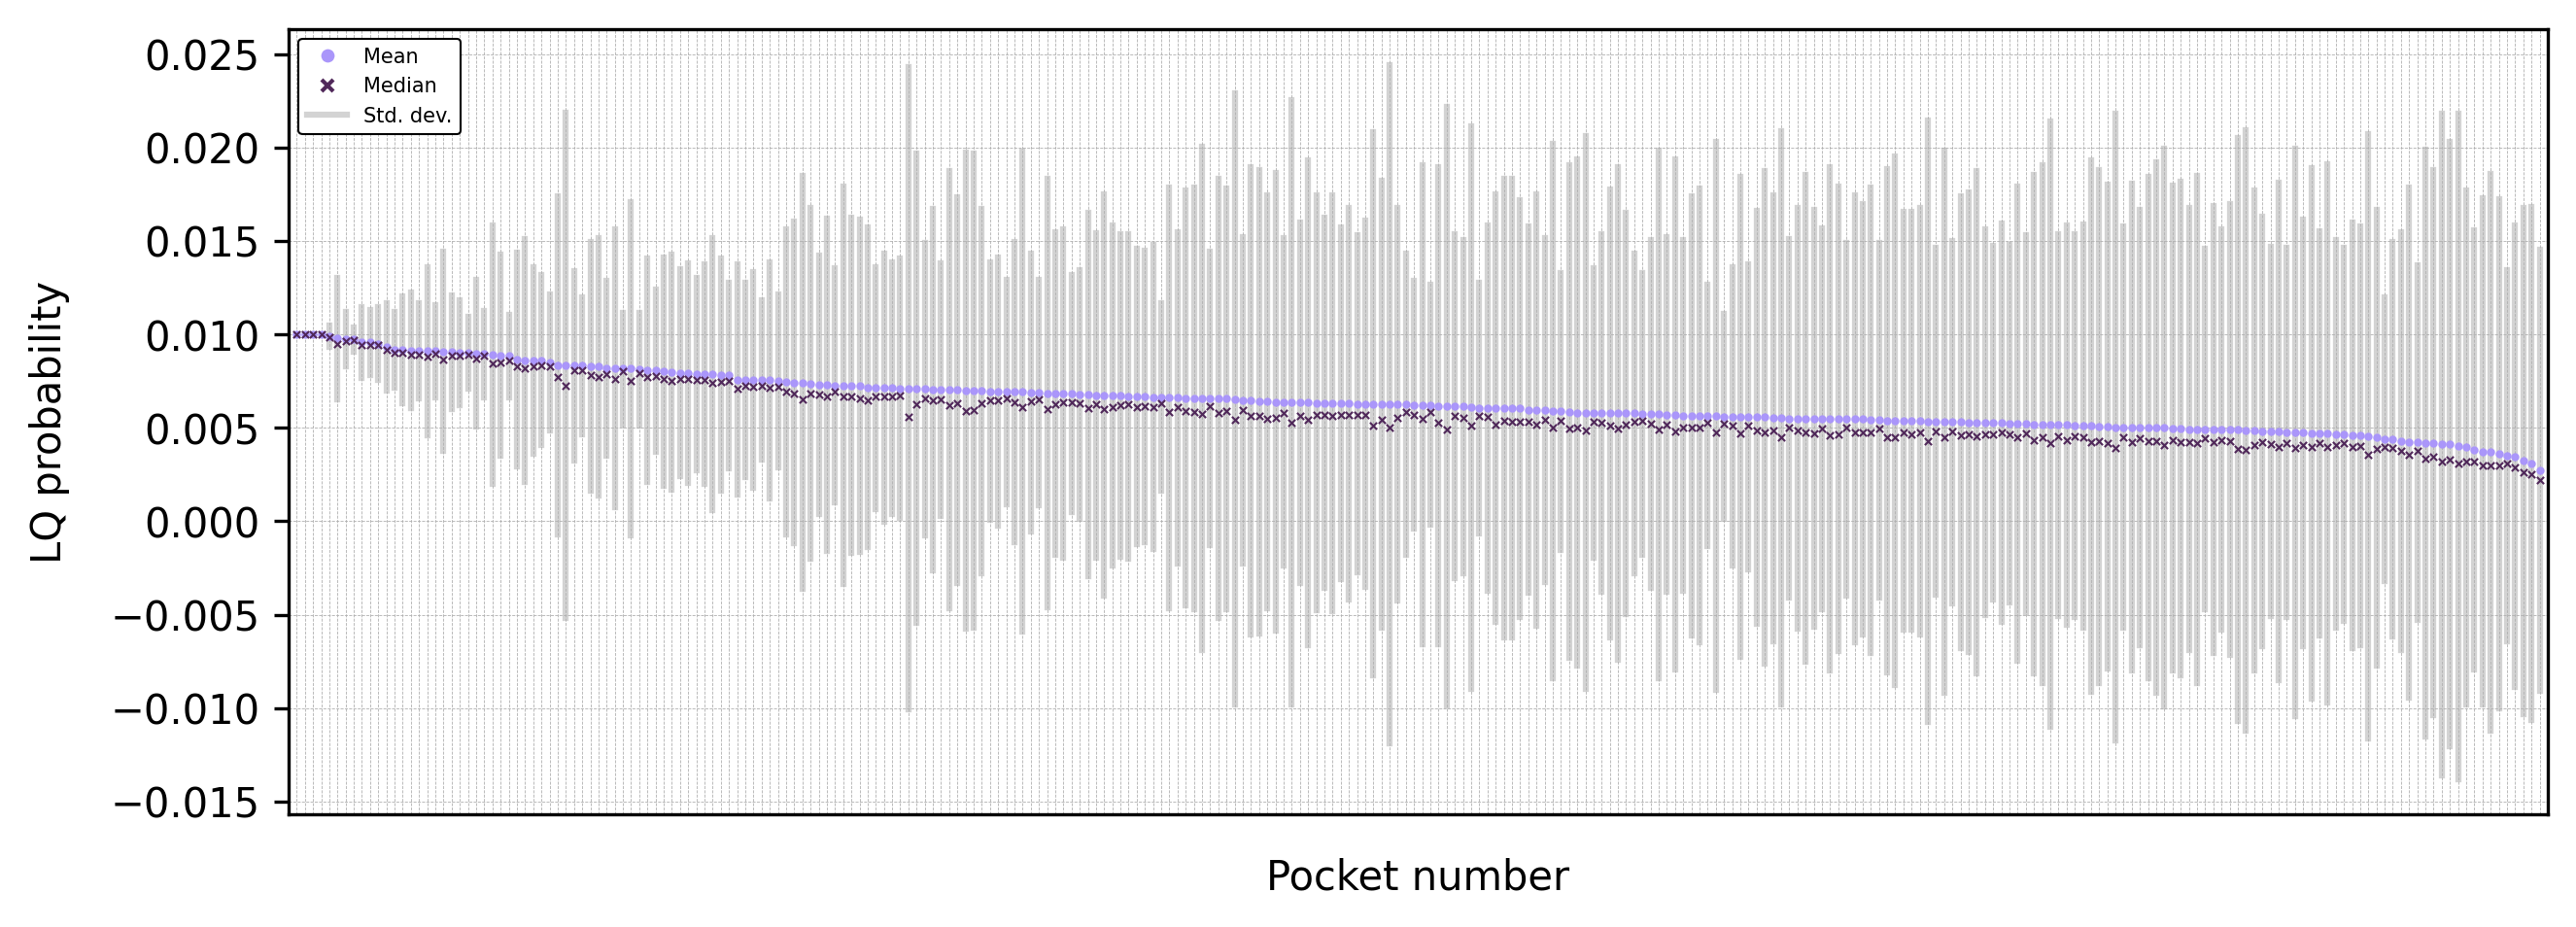

In [8]:
x, mean, median, std = [], [], [], []
for c, pocket in enumerate(pockets):
    x.append(c)
    mean.append(pocket_to_prob_mean[pocket])
    median.append(pocket_to_prob_median[pocket])
    std.append(pocket_to_prob_std[pocket])

ind = np.argsort(mean)[::-1]
mean, median, std = np.array(mean)[ind], np.array(median)[ind], np.array(std)[ind]

legend_elements = [
    Line2D([0], [0], marker='o', color='none', label="Mean", markerfacecolor="#AA96FA", markeredgecolor="w", markeredgewidth=0.7, markersize=4, linestyle="None"),
    Line2D([0], [0], marker='x', color='#50285A', label="Median", markersize=3, linestyle="None"),
    Line2D([0], [0], color='lightgray', label="Std. dev.", linewidth=1.5, linestyle='-')
]
 
fig, ax = plt.subplots(figsize=(10, 3.5))
plt.scatter(x, mean, zorder=2, s=1, c="#AA96FA")
plt.scatter(x, median, zorder=2, s=3, marker='x', lw=0.5, c='#50285A')
for c, (i, j) in enumerate(zip(mean, std)):
    plt.plot([c, c], [i+j, i-j], zorder=-2, c='lightgray', lw=1.5)
plt.xticks([i for i in range(len(pockets))], ["" for i in range(len(pockets))])
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-6, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("LQ probability", labelpad=10)
plt.xlim([-1, 276])
l = plt.legend(handles=legend_elements, prop={'size': 5}, edgecolor='k', framealpha=1, loc='best')
l.get_frame().set_linewidth(0.5)
plt.show()

In [9]:
max(mean), min(mean)

(np.float32(0.010041927), np.float32(0.0027339496))

In [10]:
sorted(std)[:5]

[np.float32(4.5831584e-08),
 np.float32(8.2871836e-08),
 np.float32(8.911114e-08),
 np.float32(1.0187836e-07),
 np.float32(0.0005867604)]

In [11]:
### HIT OVERLAP ###

In [12]:
TOPs = [100, 1000, 10000, 100000]
l = len(pockets)
HIT_OVERLAP = {i: {} for i in TOPs}

pocket_to_inds = {}
# For each pocket
for pocket in tqdm(pockets):
    # Get indices that sort probs - limited to MAX(TOPs)
    ind = np.argsort(pocket_to_all_probs[pocket])[::-1][:max(TOPs)]
    pocket_to_inds[pocket] = np.array(ind, dtype='int32')

100%|██████████| 276/276 [02:42<00:00,  1.70it/s]


In [13]:
# For each pocket1
for c1, pocket1 in tqdm(enumerate(pockets)):
    # For each pocket2
    for c2, pocket2 in enumerate(pockets[c1:]):
        # For each hit set
        for c3, TOP in enumerate(TOPs):
            h1 = pocket_to_inds[pocket1][:TOP]
            h2 = pocket_to_inds[pocket2][:TOP]
            HIT_OVERLAP[TOP][(pocket1, pocket2)] = np.intersect1d(h1, h2).size
            HIT_OVERLAP[TOP][(pocket2, pocket1)] = HIT_OVERLAP[TOP][(pocket1, pocket2)]

276it [01:51,  2.48it/s]


In [14]:
diff_protein = {i: {} for i in TOPs}
same_protein = {i: {} for i in TOPs}
same_pocket = {i: {} for i in TOPs}

for c, pocket1 in tqdm(enumerate(pockets)):
    for pocket2 in pockets[c+1:]:

        # Define pair
        pair = (pocket1, pocket2)
        
        # If the protein is different
        if pocket1.split("_")[1] != pocket2.split("_")[1]:
            for TOP in TOPs:
                diff_protein[TOP][pair] = HIT_OVERLAP[TOP][pair]

        else:

            # Calculate distance
            d = distance.euclidean(pocket_to_coords[pocket1], pocket_to_coords[pocket2])

            # If the pocket is the same
            if d < 6.14:
                for TOP in TOPs:
                    same_pocket[TOP][pair] = HIT_OVERLAP[TOP][pair]

            # If the pocket is not the same
            else:
                for TOP in TOPs:
                    same_protein[TOP][pair] = HIT_OVERLAP[TOP][pair]

276it [00:00, 2809.53it/s]


In [15]:
# for TOP in TOPs:

#     plt.figure(figsize=(3.5, 2))

#     bins = np.linspace(0, TOP, 35)
#     plt.hist(np.array(list(diff_protein[TOP].values())), bins=bins, edgecolor='k', linewidth=0.5, color="#50285A", label=f'Different protein ({len(diff_protein[TOP])})', zorder=2, density=True)
#     plt.hist(np.array(list(same_protein[TOP].values())), bins=bins, edgecolor='k', linewidth=0.5, color="#FAD782", label=f'Same prot - diff pocket ({len(same_protein[TOP])})', zorder=2, density=True, alpha=0.85)
#     plt.hist(np.array(list(same_pocket[TOP].values())), bins=bins, edgecolor='k', linewidth=0.5, color="#BEE6B4", label=f'Same pocket ({len(same_pocket[TOP])})', zorder=2, density=True, alpha=0.75)

#     title = f'TOP-{TOP} hits' + "\n" + "Same pocket defined at 6.14 A"
#     plt.title(title, pad=10)
#     plt.gca().set_yticklabels([])
#     plt.xlabel("Number of hits", labelpad=10)
#     plt.ylabel("Density", labelpad=8)
#     plt.grid(linestyle='--', zorder=-2)
#     l = plt.legend(framealpha=1, edgecolor='k', prop={'size': 5.1})
#     l.get_frame().set_linewidth(0.6)
#     plt.show()

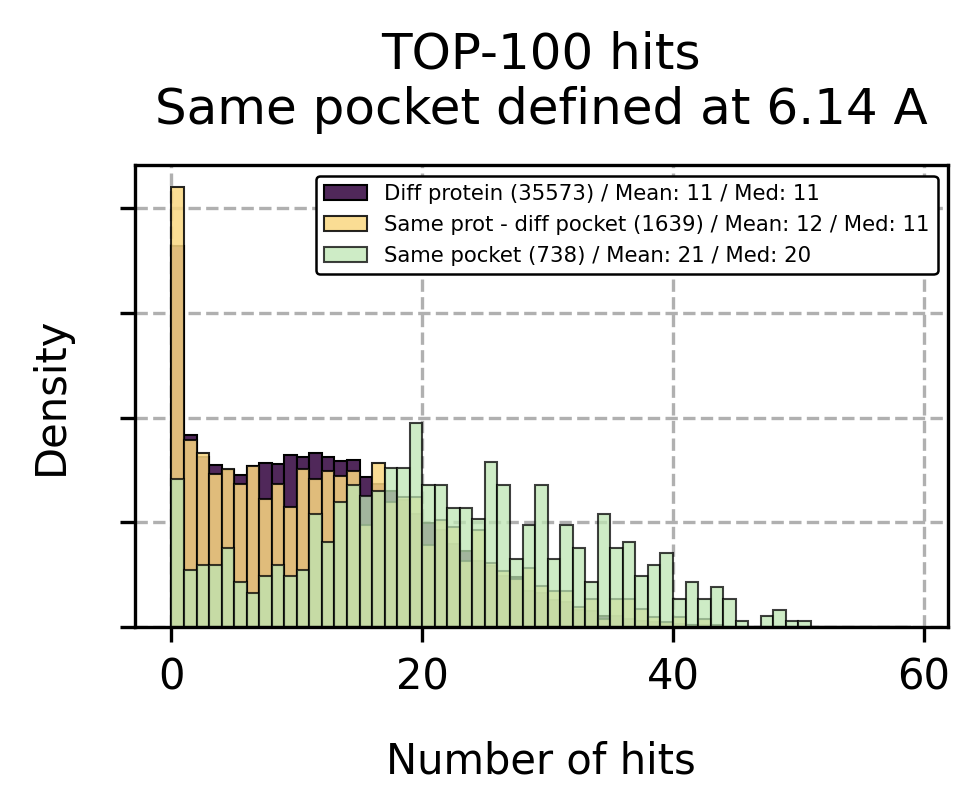

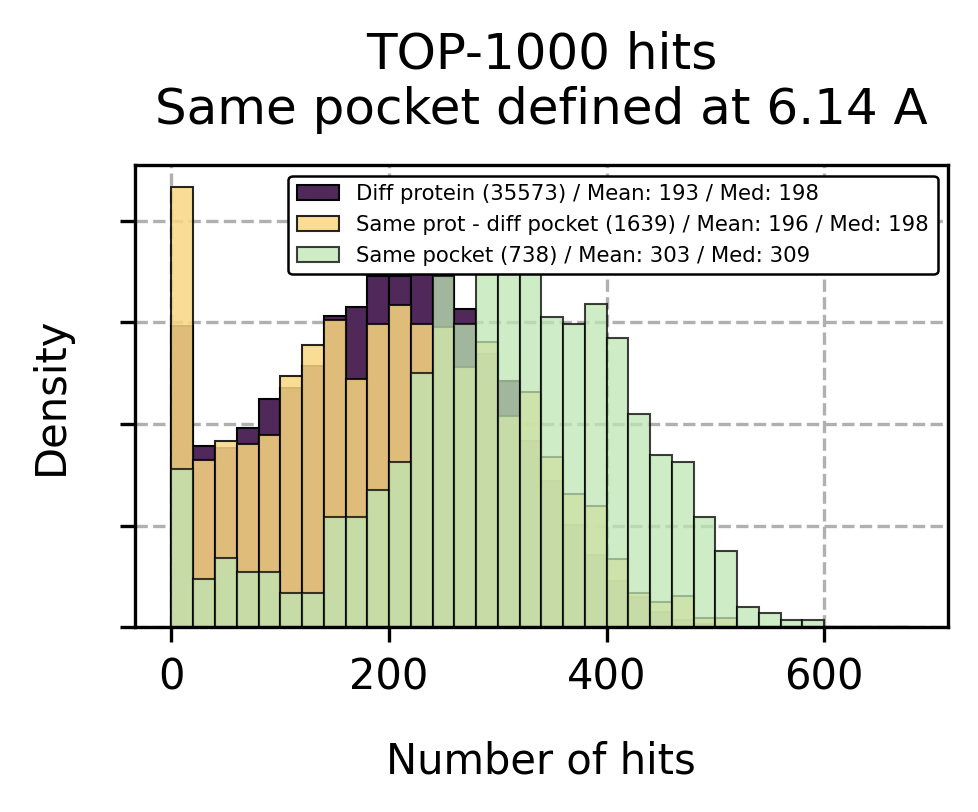

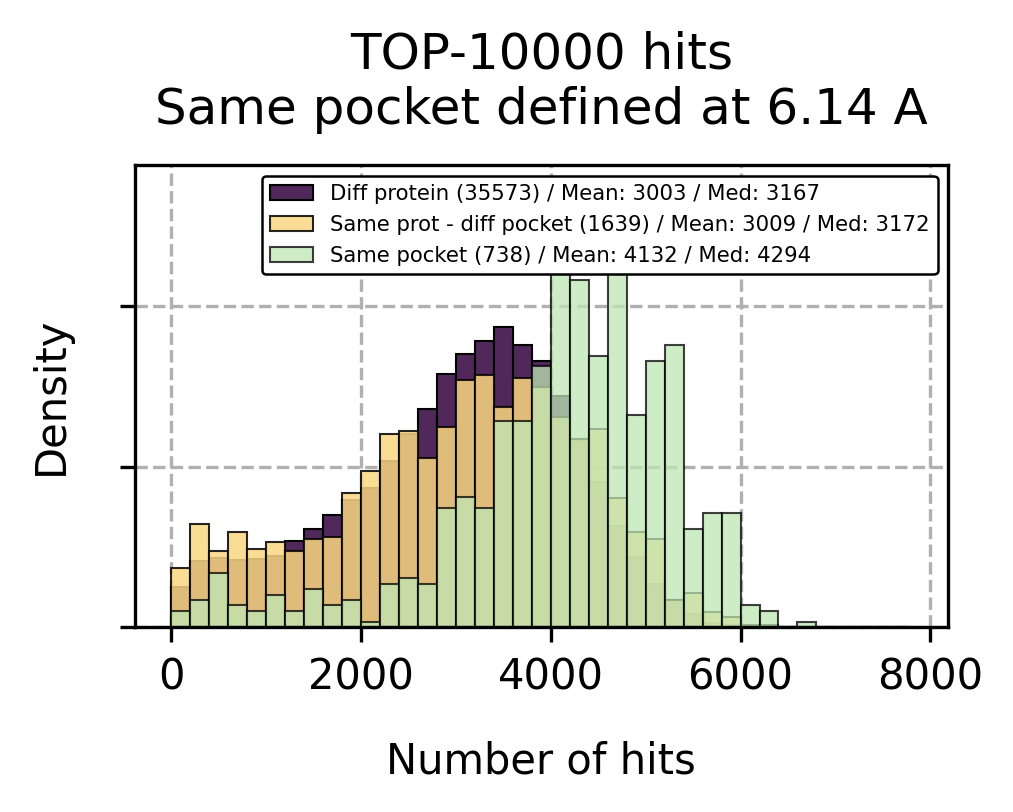

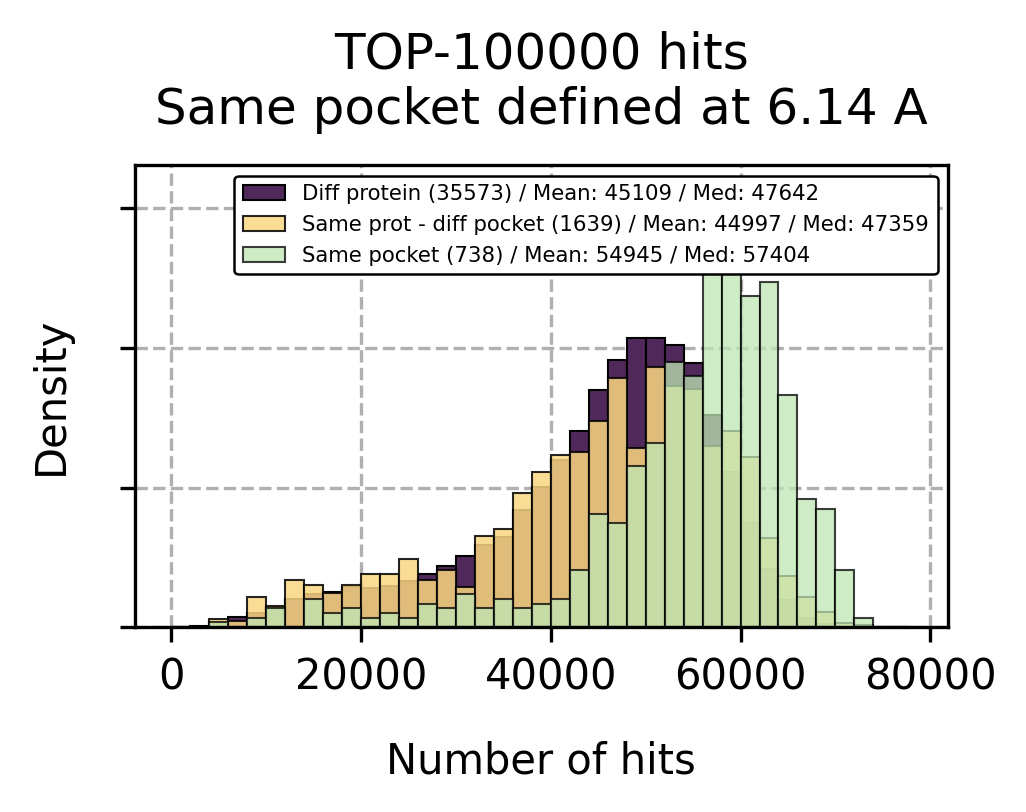

In [24]:
TOP_TO_BINS = {100: [i for i in range(0, 60, 1)],
               1000: [i for i in range(0, 700, 20)],
               10000: [i for i in range(0, 8000, 200)],
               100000: [i for i in range(0, 80000, 2000)]}

for TOP in TOPs:

    plt.figure(figsize=(3.5, 2))

    bins = TOP_TO_BINS[TOP]
    h1 = np.array(list(diff_protein[TOP].values()))
    h2 = np.array(list(same_protein[TOP].values()))
    h3 = np.array(list(same_pocket[TOP].values()))
    label1 = f'Diff protein ({len(diff_protein[TOP])}) / Mean: {int(np.mean(h1))} / Med: {int(np.median(h1))}'
    label2 = f'Same prot - diff pocket ({len(same_protein[TOP])}) / Mean: {int(np.mean(h2))} / Med: {int(np.median(h2))}'
    label3 = f'Same pocket ({len(same_pocket[TOP])}) / Mean: {int(np.mean(h3))} / Med: {int(np.median(h3))}'
    plt.hist(h1, bins=bins, edgecolor='k', linewidth=0.5, color="#50285A", label=label1, zorder=2, density=True)
    plt.hist(h2, bins=bins, edgecolor='k', linewidth=0.5, color="#FAD782", label=label2, zorder=2, density=True, alpha=0.85)
    plt.hist(h3, bins=bins, edgecolor='k', linewidth=0.5, color="#BEE6B4", label=label3, zorder=2, density=True, alpha=0.75)

    title = f'TOP-{TOP} hits' + "\n" + "Same pocket defined at 6.14 A"
    plt.title(title, pad=10)
    plt.gca().set_yticklabels([])
    plt.xlabel("Number of hits", labelpad=10)
    plt.ylabel("Density", labelpad=8)
    plt.grid(linestyle='--', zorder=-2)
    l = plt.legend(framealpha=1, edgecolor='k', prop={'size': 5.1})
    l.get_frame().set_linewidth(0.6)
    plt.show()

In [25]:
### Sanity check

p1 = 'swissmodel_P9WFW7_model_0_pocket_1'
p2 = 'chai1_P9WQA1_model_2_pocket_2'

print(HIT_OVERLAP[10000][(p1, p2)])
l1 = set(labels[np.argsort(pocket_to_all_probs[p1])[::-1]][:10000])
l2 = set(labels[np.argsort(pocket_to_all_probs[p2])[::-1]][:10000])
print(len(l1.intersection(l2)))

1550
1550


In [26]:
### PROBABILITY MATRIX

# Prepare matrix
df = np.column_stack([pocket_to_all_probs[p] for p in pockets])

# Calculate average values
means = np.mean(df, axis=1)

In [27]:
# Define x space
xs = np.linspace(0, 1, 1000)

# Calculate # compounds having prob >= x
y = [np.where(means >= i)[0].shape[0] for i in xs]

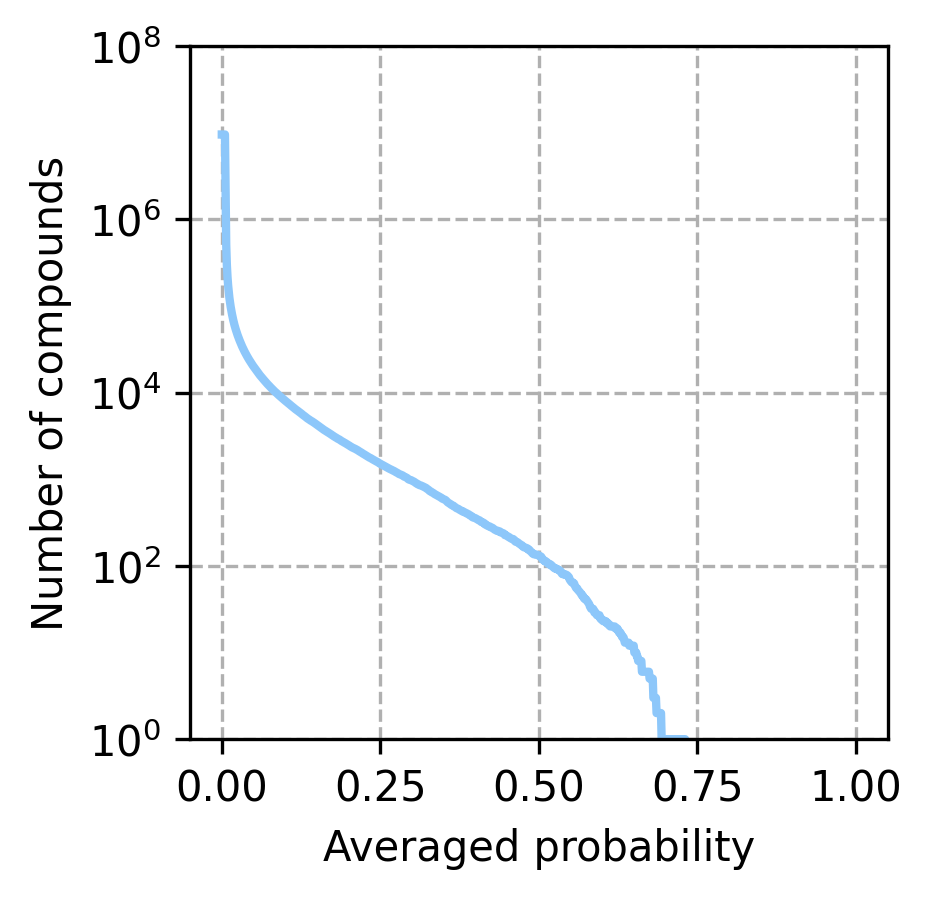

In [28]:
plt.figure(figsize=(3, 3))
plt.plot(xs, y, c='#8DC7FA', lw=2)
plt.yscale('log')
plt.ylim([1, 1e8])
plt.grid(linestyle='--', zorder=-2)
plt.xlabel("Averaged probability")
plt.ylabel("Number of compounds")
plt.show()

In [29]:
### Study frequent hitters

TOPs = [100, 1000, 10000, 100000]
hits = {}
for top in TOPs:
    h = [i for pocket in pocket_to_inds for i in pocket_to_inds[pocket][:top]]
    hits[top] = dict(Counter(h))

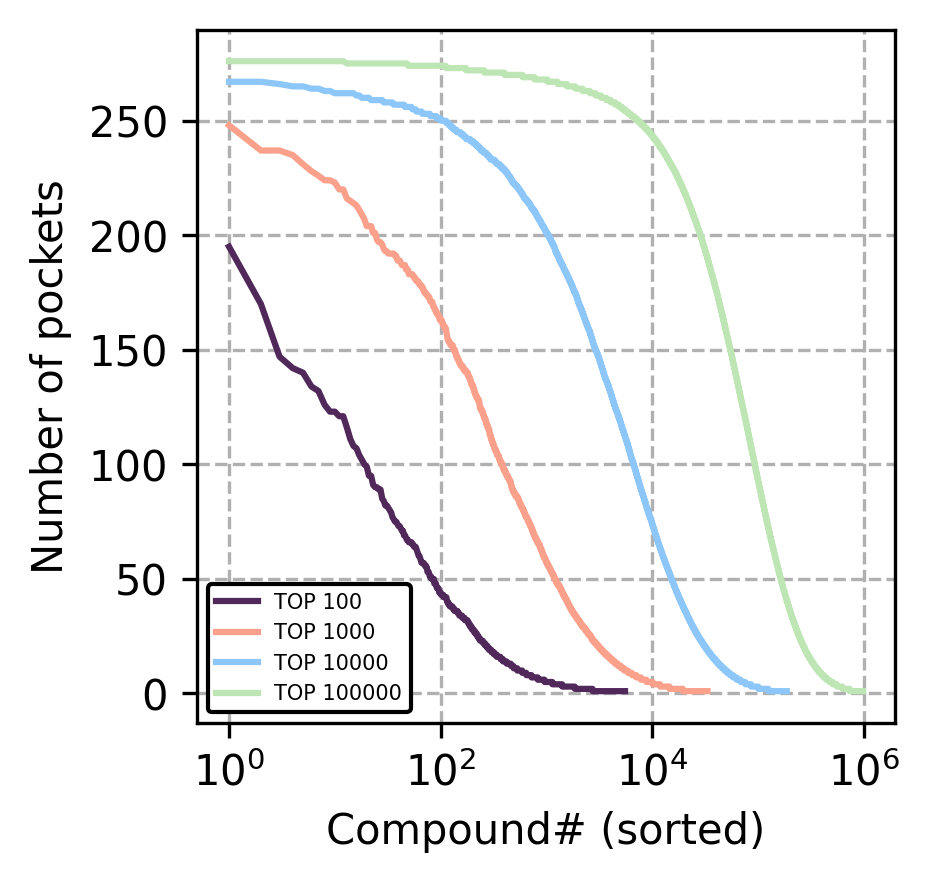

In [30]:
plt.figure(figsize=(3, 3))
colors = ['#50285A', '#FAA08B', '#8DC7FA', '#BEE6B4']
for c, top in zip(colors, TOPs):
    plt.plot([i+1 for i in range(len(hits[top]))], sorted(hits[top].values())[::-1], color=c, label=f'TOP {top}')
plt.grid(linestyle='--', zorder=-2)
plt.xscale('log')
plt.xlabel("Compound# (sorted)")
plt.ylabel("Number of pockets")
plt.xticks([1, 100, 10000, 1000000])
plt.legend(prop={'size':5}, edgecolor='k', framealpha=1, loc='lower left')
plt.show()